## Phase 1: Run Linear Probes on Single Datasets: Mistral-7B on SQuAD (2k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_005740-vqz16d4s/files')  # path for mistral-7b on squad (2k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-u9vlq8r6 because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Utility Functions

In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [4]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([2.1640, 0.8018, 2.1640,  ..., 1.6957, 2.1640, 1.7481])


In [5]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

In [6]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
ca_entropy = entropy.to(torch.float32)
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.6659) tensor(0.6312)
torch.Size([2000, 33, 4096]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [7]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4096])


In [8]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [9]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [10]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

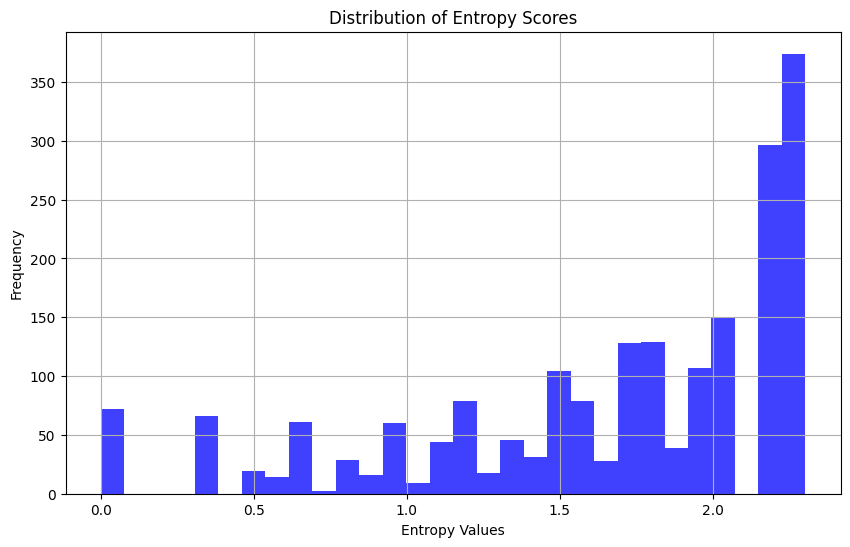

In [11]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.3722477007797926

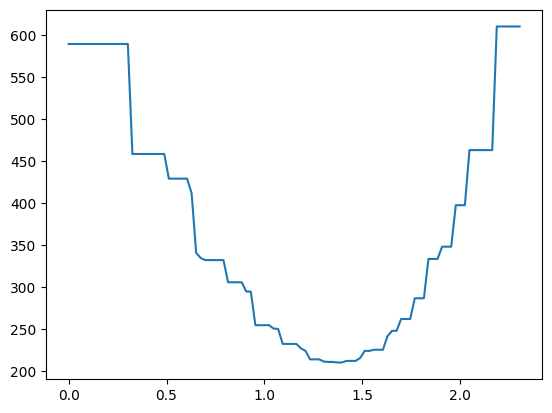

In [12]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [13]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

# bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.6115


In [14]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [15]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6028, AUROC: 0.6691
Training Loss: 0.6467, Validation Loss: 0.6545
Test Loss: 0.6250, Test Accuracy: 0.6750, AUROC: 0.6468
Training on Dataset 2/33
Validation Accuracy: 0.6389, AUROC: 0.7156
Training Loss: 0.6077, Validation Loss: 0.6241
Test Loss: 0.6023, Test Accuracy: 0.6950, AUROC: 0.6744
Training on Dataset 3/33
Validation Accuracy: 0.6833, AUROC: 0.7340
Training Loss: 0.5675, Validation Loss: 0.5996
Test Loss: 0.5941, Test Accuracy: 0.6900, AUROC: 0.6765
Training on Dataset 4/33
Validation Accuracy: 0.6861, AUROC: 0.7368
Training Loss: 0.5263, Validation Loss: 0.5901
Test Loss: 0.5941, Test Accuracy: 0.6750, AUROC: 0.6753
Training on Dataset 5/33
Validation Accuracy: 0.6944, AUROC: 0.7487
Training Loss: 0.4790, Validation Loss: 0.5809
Test Loss: 0.6043, Test Accuracy: 0.6800, AUROC: 0.6647
Training on Dataset 6/33
Validation Accuracy: 0.7056, AUROC: 0.7653
Training Loss: 0.4320, Validation Loss: 0.5651
Test Loss: 0.5968, Test Accura

In [16]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.7911 at layer 31


In [18]:
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests):
    X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
    X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_train_cc = y_trains[layer_range[0]]
    y_val_cc = y_vals[layer_range[0]]
    y_test_cc = y_tests[layer_range[0]]
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

In [19]:
# Save models for testing on Accuracy
tblr_best_auc_indices = np.argsort(tblr_test_aucs)[::-1]

topktblr_test_accs = {}
topktblr_test_aucs = {}
topktblr_models = {}

for top_k in range(1, 10):
    indices = tblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktblr_test_accs[tuple(indices)] = test_acc
    topktblr_test_aucs[tuple(indices)] = test_auc
    topktblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [31]
Validation Accuracy: 0.7611, AUROC: 0.7973
Training Loss: 0.0070, Validation Loss: 0.8785
Test Loss: 0.8269, Test Accuracy: 0.7400, AUROC: 0.7911
Training on top-2 Datasets indexed [31, 32]
Validation Accuracy: 0.7611, AUROC: 0.8050
Training Loss: 0.0037, Validation Loss: 0.9125
Test Loss: 0.8630, Test Accuracy: 0.7600, AUROC: 0.7952
Training on top-3 Datasets indexed [31, 32, 30]
Validation Accuracy: 0.7556, AUROC: 0.8019
Training Loss: 0.0027, Validation Loss: 0.9586
Test Loss: 0.9186, Test Accuracy: 0.7550, AUROC: 0.7946
Training on top-4 Datasets indexed [31, 32, 30, 29]
Validation Accuracy: 0.7639, AUROC: 0.8047
Training Loss: 0.0024, Validation Loss: 0.9811
Test Loss: 0.9657, Test Accuracy: 0.7450, AUROC: 0.7884
Training on top-5 Datasets indexed [31, 32, 30, 29, 11]
Validation Accuracy: 0.7750, AUROC: 0.8061
Training Loss: 0.0022, Validation Loss: 1.0068
Test Loss: 0.9949, Test Accuracy: 0.7450, AUROC: 0.7902
Training on top-6 Datasets ind

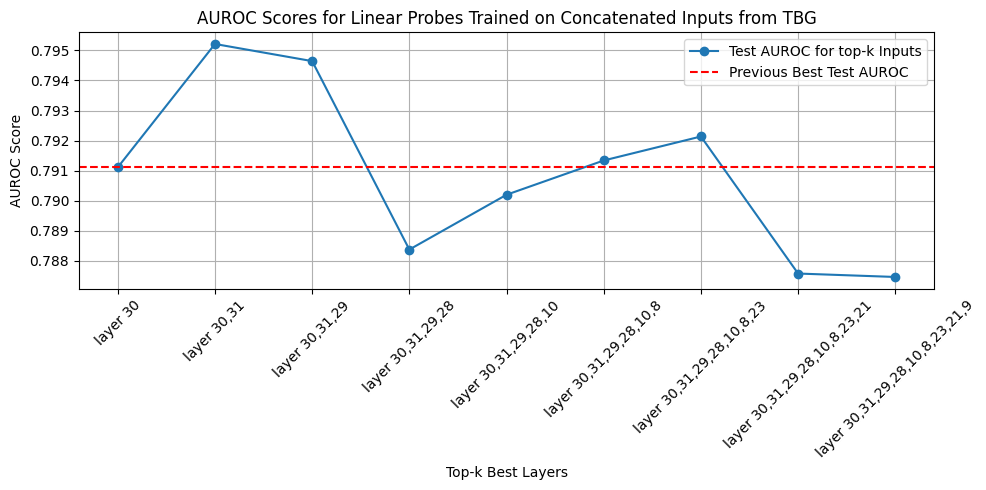

In [20]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(tblr_test_aucs), topktblr_test_aucs, 'TBG')

### Explore Second Last generated Token (SLT)


In [21]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4096])


In [22]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4096])

In [23]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4096]) torch.float32


In [24]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [25]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6028, AUROC: 0.5000
Training Loss: 0.6710, Validation Loss: 0.6719
Test Loss: 0.6411, Test Accuracy: 0.6750, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.6028, AUROC: 0.4802
Training Loss: 0.6710, Validation Loss: 0.6719
Test Loss: 0.6411, Test Accuracy: 0.6750, AUROC: 0.4710
Training on Dataset 3/33
Validation Accuracy: 0.6028, AUROC: 0.4745
Training Loss: 0.6710, Validation Loss: 0.6719
Test Loss: 0.6412, Test Accuracy: 0.6750, AUROC: 0.5002
Training on Dataset 4/33
Validation Accuracy: 0.6028, AUROC: 0.6566
Training Loss: 0.6635, Validation Loss: 0.6644
Test Loss: 0.6385, Test Accuracy: 0.6750, AUROC: 0.5657
Training on Dataset 5/33
Validation Accuracy: 0.6028, AUROC: 0.7053
Training Loss: 0.6536, Validation Loss: 0.6535
Test Loss: 0.6346, Test Accuracy: 0.6750, AUROC: 0.5909
Training on Dataset 6/33
Validation Accuracy: 0.6500, AUROC: 0.7510
Training Loss: 0.6279, Validation Loss: 0.6255
Test Loss: 0.6230, Test Accura

In [26]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.7877 at layer 32


In [27]:
# Select best top-k layers 
sblr_best_auc_indices = np.argsort(sblr_test_aucs)[::-1]

topksblr_test_accs = {}
topksblr_test_aucs = {}
topksblr_models = {}

for top_k in range(1, 10):
    indices = sblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksblr_test_accs[tuple(indices)] = test_acc
    topksblr_test_aucs[tuple(indices)] = test_auc
    topksblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [32]
Validation Accuracy: 0.7750, AUROC: 0.8382
Training Loss: 0.0062, Validation Loss: 0.7748
Test Loss: 0.9990, Test Accuracy: 0.7150, AUROC: 0.7877
Training on top-2 Datasets indexed [32, 31]
Validation Accuracy: 0.7694, AUROC: 0.8340
Training Loss: 0.0038, Validation Loss: 0.8498
Test Loss: 1.0663, Test Accuracy: 0.7200, AUROC: 0.7802
Training on top-3 Datasets indexed [32, 31, 33]
Validation Accuracy: 0.7639, AUROC: 0.8256
Training Loss: 0.0002, Validation Loss: 1.3249
Test Loss: 1.7441, Test Accuracy: 0.6950, AUROC: 0.7675
Training on top-4 Datasets indexed [32, 31, 33, 18]
Validation Accuracy: 0.7694, AUROC: 0.8266
Training Loss: 0.0002, Validation Loss: 1.3326
Test Loss: 1.7503, Test Accuracy: 0.6950, AUROC: 0.7684
Training on top-5 Datasets indexed [32, 31, 33, 18, 20]
Validation Accuracy: 0.7667, AUROC: 0.8264
Training Loss: 0.0002, Validation Loss: 1.3223
Test Loss: 1.7416, Test Accuracy: 0.6950, AUROC: 0.7672
Training on top-6 Datasets ind

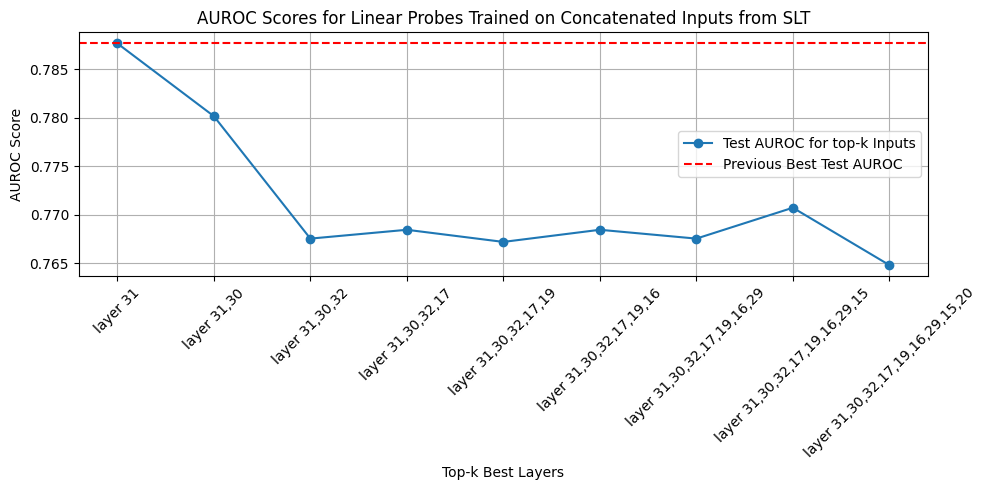

In [28]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(sblr_test_aucs), topksblr_test_aucs, 'SLT')

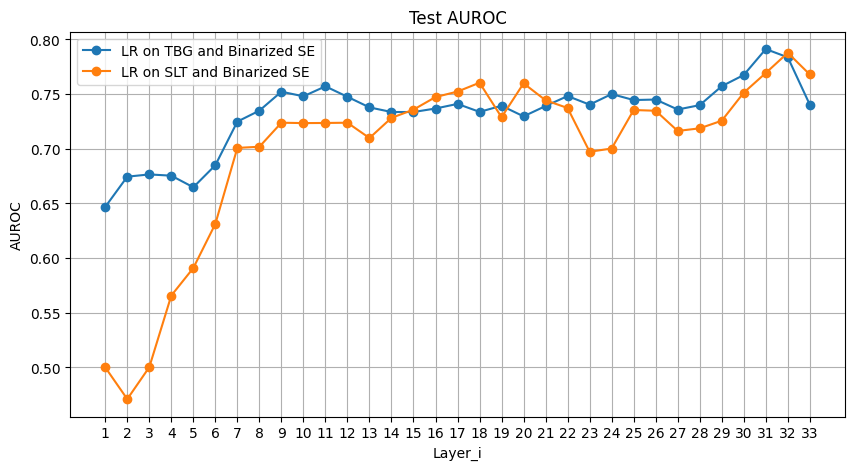

TBG: max AUROC for LR trained and tested on Binarized SE: 0.7911 at 31 layer
SLT: max AUROC for LR trained and tested on Binarized SE: 0.7877 at 32 layer


In [29]:
plot_1d_metrics([tblr_test_aucs, sblr_test_aucs], ['LR on TBG and Binarized SE', 'LR on SLT and Binarized SE'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Binarized SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binarized SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [30]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([1., 0., 0., 1., 1., 0., 0., 0., 0., 0.])


In [31]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [32]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.7750


In [33]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.8194, AUROC: 0.5605
Training Loss: 0.5108, Validation Loss: 0.4742
Test Loss: 0.5305, Test Accuracy: 0.7750, AUROC: 0.6173
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.8194, AUROC: 0.5942
Training Loss: 0.4958, Validation Loss: 0.4688
Test Loss: 0.5192, Test Accuracy: 0.7750, AUROC: 0.6598
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.8194, AUROC: 0.6052
Training Loss: 0.4734, Validation Loss: 0.4648
Test Loss: 0.5102, Test Accuracy: 0.7750, AUROC: 0.6771
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.8194, AUROC: 0.6088
Training Loss: 0.4409, Validation Loss: 0.4627
Test Loss: 0.5070, Test Accuracy: 0.7800, AUROC: 0.6523
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.8194, AUROC: 0.6224
Training Loss: 0.4063, Validation Loss: 0.4597
Test Loss: 0.4960, Test Accuracy: 0.7800, AUROC: 0.6889
Training on TBG-Acc Dataset 6/33
Validation Accuracy: 0.8222, AUROC: 0.6526
Training Loss: 0.3698, Valida

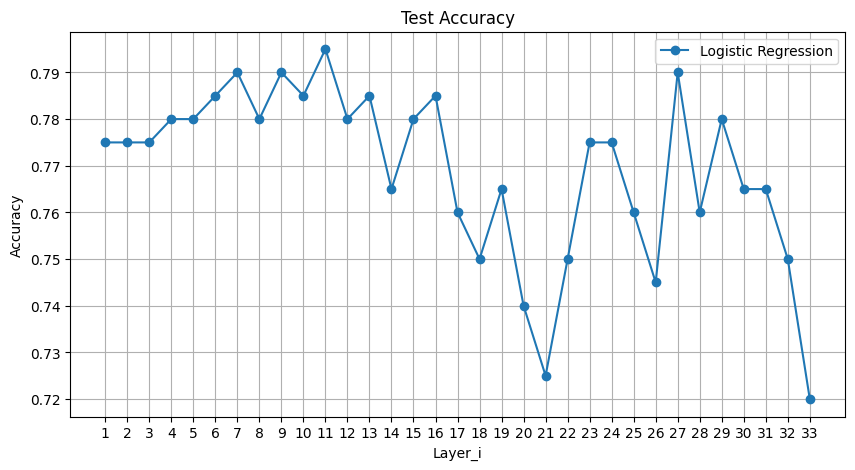

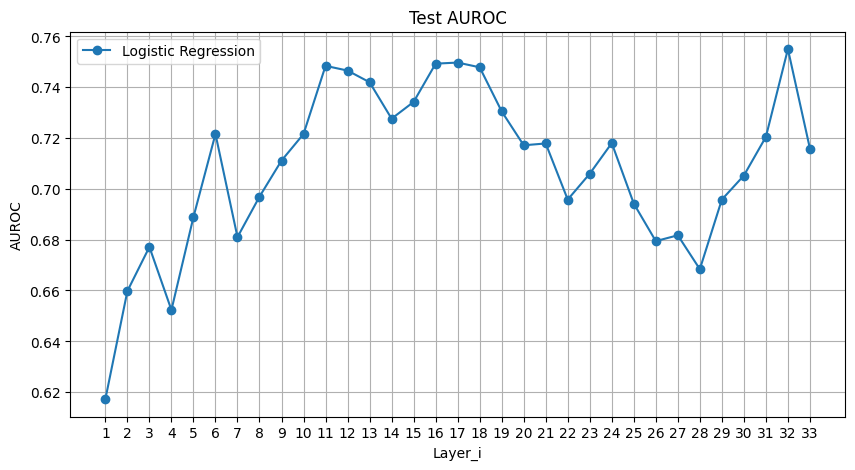

In [34]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [35]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.7550 at layer 32


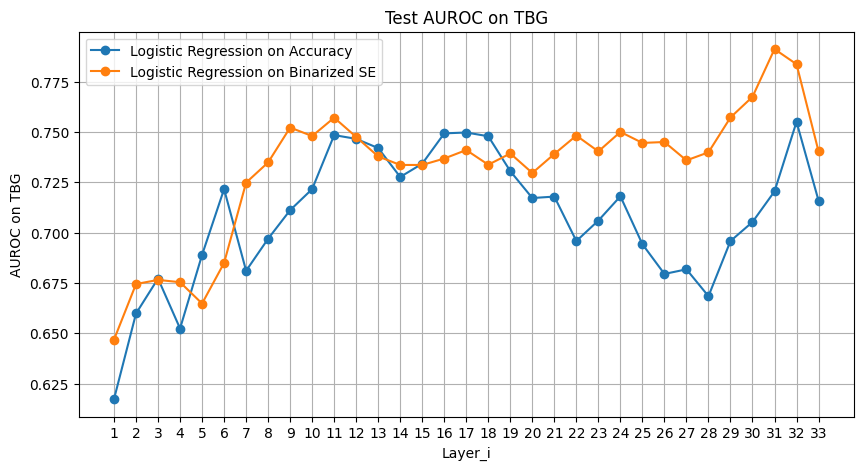

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7550 at 32 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.7911 at 31 layer


In [36]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [37]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [38]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.8194, AUROC: 0.5000
Training Loss: 0.5163, Validation Loss: 0.4753
Test Loss: 0.5337, Test Accuracy: 0.7750, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.8194, AUROC: 0.4581
Training Loss: 0.5164, Validation Loss: 0.4753
Test Loss: 0.5337, Test Accuracy: 0.7750, AUROC: 0.4493
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.8194, AUROC: 0.5174
Training Loss: 0.5158, Validation Loss: 0.4752
Test Loss: 0.5334, Test Accuracy: 0.7750, AUROC: 0.5287
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.8194, AUROC: 0.5706
Training Loss: 0.5130, Validation Loss: 0.4739
Test Loss: 0.5316, Test Accuracy: 0.7750, AUROC: 0.5709
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.8194, AUROC: 0.6257
Training Loss: 0.5074, Validation Loss: 0.4707
Test Loss: 0.5290, Test Accuracy: 0.7750, AUROC: 0.6090
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.8194, AUROC: 0.6353
Training Loss: 0.4919, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8194, AUROC: 0.7446
Training Loss: 0.2389, Validation Loss: 0.4233
Test Loss: 0.5033, Test Accuracy: 0.7750, AUROC: 0.7128
Training on SLT-Acc Dataset 15/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8194, AUROC: 0.7253
Training Loss: 0.2001, Validation Loss: 0.4487
Test Loss: 0.4954, Test Accuracy: 0.7900, AUROC: 0.7384
Training on SLT-Acc Dataset 16/33
Validation Accuracy: 0.8278, AUROC: 0.7301
Training Loss: 0.1770, Validation Loss: 0.4381
Test Loss: 0.5168, Test Accuracy: 0.8000, AUROC: 0.7196
Training on SLT-Acc Dataset 17/33
Validation Accuracy: 0.8139, AUROC: 0.7332
Training Loss: 0.1291, Validation Loss: 0.4709
Test Loss: 0.5113, Test Accuracy: 0.7950, AUROC: 0.7429
Training on SLT-Acc Dataset 18/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8056, AUROC: 0.7322
Training Loss: 0.0973, Validation Loss: 0.4891
Test Loss: 0.5725, Test Accuracy: 0.7900, AUROC: 0.7263
Training on SLT-Acc Dataset 19/33
Validation Accuracy: 0.8306, AUROC: 0.7566
Training Loss: 0.0844, Validation Loss: 0.4764
Test Loss: 0.5866, Test Accuracy: 0.7750, AUROC: 0.7220
Training on SLT-Acc Dataset 20/33
Validation Accuracy: 0.8000, AUROC: 0.7422
Training Loss: 0.0636, Validation Loss: 0.5406
Test Loss: 0.5628, Test Accuracy: 0.7750, AUROC: 0.7503
Training on SLT-Acc Dataset 21/33
Validation Accuracy: 0.7833, AUROC: 0.7234
Training Loss: 0.0450, Validation Loss: 0.6195
Test Loss: 0.6092, Test Accuracy: 0.8000, AUROC: 0.7389
Training on SLT-Acc Dataset 22/33
Validation Accuracy: 0.7778, AUROC: 0.7123
Training Loss: 0.0320, Validation Loss: 0.6585
Test Loss: 0.6166, Test Accuracy: 0.7700, AUROC: 0.7326
Training on SLT-Acc Dataset 23/33
Validation Accuracy: 0.7778, AUROC: 0.7249
Training Loss: 0.0254, Validation Loss: 0.6523
Test Loss:

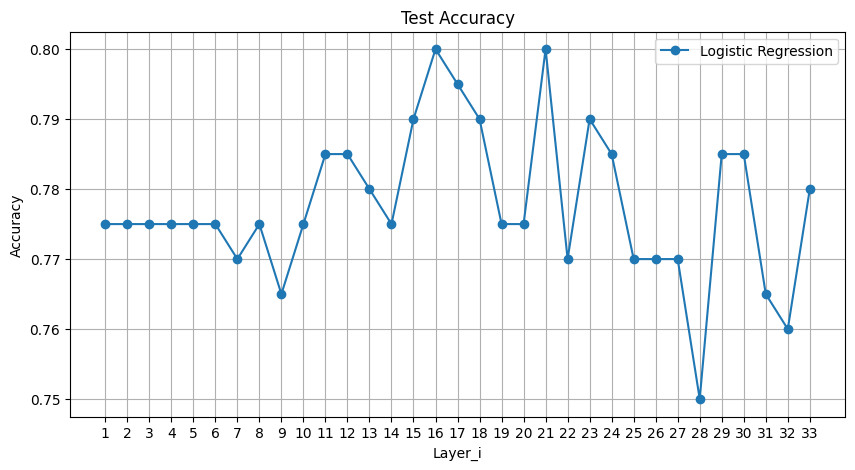

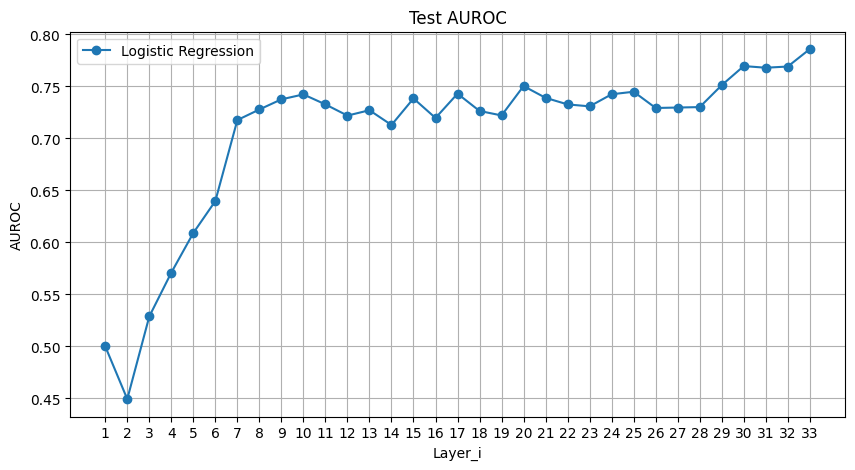

In [39]:
plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [40]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.7858 at layer 33


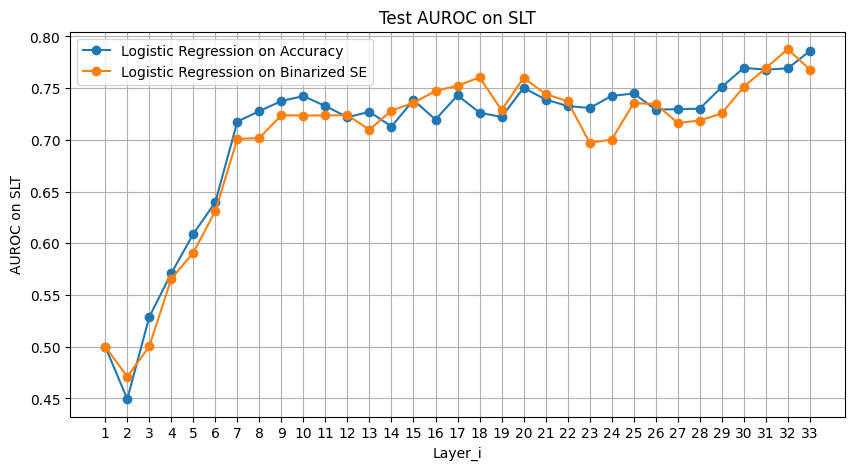

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7858 at 33 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.7877 at 32 layer


In [41]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [42]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [43]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.6028, AUROC: 0.6691
Training Loss: 0.6467, Validation Loss: 0.6545
Test Loss: 0.5905, Test Accuracy: 0.7750, AUROC: 0.6365
Training on TBG Dataset 2/33
Validation Accuracy: 0.6389, AUROC: 0.7156
Training Loss: 0.6077, Validation Loss: 0.6241
Test Loss: 0.5757, Test Accuracy: 0.7150, AUROC: 0.6671
Training on TBG Dataset 3/33
Validation Accuracy: 0.6833, AUROC: 0.7340
Training Loss: 0.5675, Validation Loss: 0.5996
Test Loss: 0.5710, Test Accuracy: 0.6900, AUROC: 0.6727
Training on TBG Dataset 4/33
Validation Accuracy: 0.6861, AUROC: 0.7368
Training Loss: 0.5263, Validation Loss: 0.5901
Test Loss: 0.5737, Test Accuracy: 0.6850, AUROC: 0.6625
Training on TBG Dataset 5/33
Validation Accuracy: 0.6944, AUROC: 0.7487
Training Loss: 0.4790, Validation Loss: 0.5809
Test Loss: 0.5795, Test Accuracy: 0.6800, AUROC: 0.6548
Training on TBG Dataset 6/33
Validation Accuracy: 0.7056, AUROC: 0.7653
Training Loss: 0.4320, Validation Loss: 0.5651
Test L

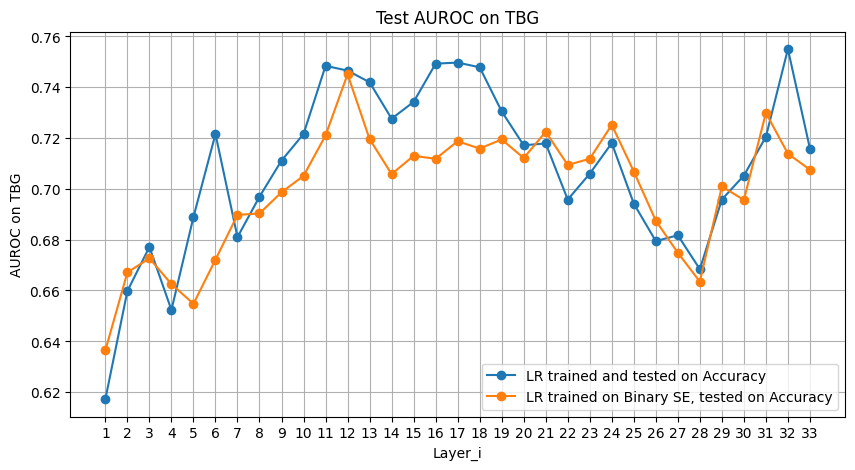

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7550 at 32 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7451 at 12 layer


In [44]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

In [45]:
## Use trained probes on concat-ed inputs of best layers
topktablr_test_accs = {}
topktablr_test_aucs = {}

for indices in topktblr_models.keys():
    print(f"Testing on top-{len(indices)} TBG Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topktblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktablr_test_accs[tuple(indices)] = test_acc
    topktablr_test_aucs[tuple(indices)] = test_auc

Testing on top-1 TBG Datasets trained probe: [30]
Test Loss: 1.0333, Test Accuracy: 0.7000, AUROC: 0.7299
Testing on top-2 TBG Datasets trained probe: [30, 31]
Test Loss: 1.1214, Test Accuracy: 0.6700, AUROC: 0.7233
Testing on top-3 TBG Datasets trained probe: [30, 31, 29]
Test Loss: 1.2002, Test Accuracy: 0.6750, AUROC: 0.7190
Testing on top-4 TBG Datasets trained probe: [30, 31, 29, 28]
Test Loss: 1.2438, Test Accuracy: 0.6650, AUROC: 0.7197
Testing on top-5 TBG Datasets trained probe: [30, 31, 29, 28, 10]
Test Loss: 1.2852, Test Accuracy: 0.6750, AUROC: 0.7234
Testing on top-6 TBG Datasets trained probe: [30, 31, 29, 28, 10, 8]
Test Loss: 1.2384, Test Accuracy: 0.6650, AUROC: 0.7209
Testing on top-7 TBG Datasets trained probe: [30, 31, 29, 28, 10, 8, 23]
Test Loss: 1.2262, Test Accuracy: 0.6900, AUROC: 0.7257
Testing on top-8 TBG Datasets trained probe: [30, 31, 29, 28, 10, 8, 23, 21]
Test Loss: 1.1986, Test Accuracy: 0.6850, AUROC: 0.7265
Testing on top-9 TBG Datasets trained probe

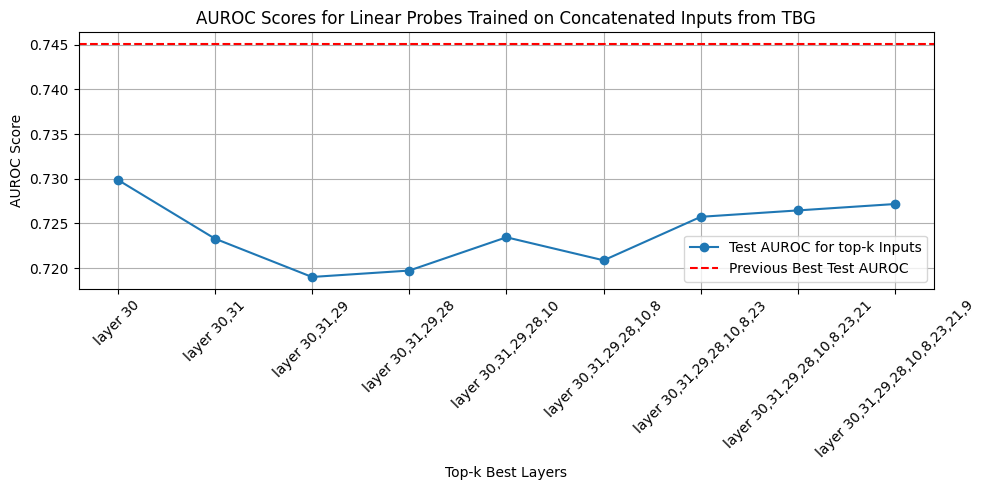

In [46]:
plot_metrics_w_constant(max(tablr_test_aucs), topktablr_test_aucs, 'TBG')

Now we test on SLT embeddings.

In [47]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [48]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.6028, AUROC: 0.5000
Training Loss: 0.6710, Validation Loss: 0.6719
Test Loss: 0.5986, Test Accuracy: 0.7750, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.6028, AUROC: 0.4802
Training Loss: 0.6710, Validation Loss: 0.6719
Test Loss: 0.5986, Test Accuracy: 0.7750, AUROC: 0.4452
Training on SLT Dataset 3/33
Validation Accuracy: 0.6028, AUROC: 0.4745
Training Loss: 0.6710, Validation Loss: 0.6719
Test Loss: 0.5986, Test Accuracy: 0.7750, AUROC: 0.4460
Training on SLT Dataset 4/33
Validation Accuracy: 0.6028, AUROC: 0.6566
Training Loss: 0.6635, Validation Loss: 0.6644
Test Loss: 0.6001, Test Accuracy: 0.7750, AUROC: 0.4887
Training on SLT Dataset 5/33
Validation Accuracy: 0.6028, AUROC: 0.7053
Training Loss: 0.6536, Validation Loss: 0.6535
Test Loss: 0.5997, Test Accuracy: 0.7750, AUROC: 0.5156
Training on SLT Dataset 6/33
Validation Accuracy: 0.6500, AUROC: 0.7510
Training Loss: 0.6279, Validation Loss: 0.6255
Test L

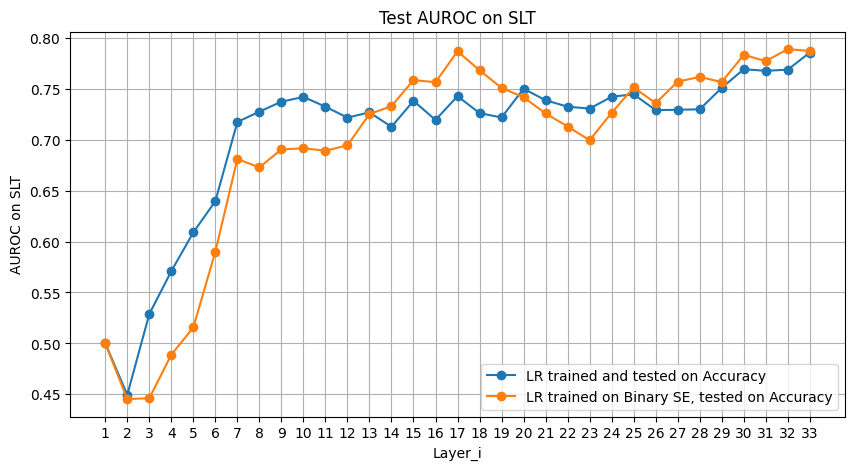

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7858 at 33 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7892 at 32 layer


In [49]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")

In [50]:
## Use trained probes on concat-ed inputs of best layers
topksablr_test_accs = {}
topksablr_test_aucs = {}

for indices in topksblr_models.keys():
    print(f"Testing on top-{len(indices)} SLT Datasets trained probe:", list(indices))
    _, _, X_test, _, _, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = topksblr_models[indices]
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksablr_test_accs[tuple(indices)] = test_acc
    topksablr_test_aucs[tuple(indices)] = test_auc

# topksablr_test_aucs

Testing on top-1 SLT Datasets trained probe: [31]
Test Loss: 1.0305, Test Accuracy: 0.7550, AUROC: 0.7892
Testing on top-2 SLT Datasets trained probe: [31, 30]
Test Loss: 1.1012, Test Accuracy: 0.7600, AUROC: 0.7858
Testing on top-3 SLT Datasets trained probe: [31, 30, 32]
Test Loss: 1.6791, Test Accuracy: 0.7550, AUROC: 0.7871
Testing on top-4 SLT Datasets trained probe: [31, 30, 32, 17]
Test Loss: 1.6957, Test Accuracy: 0.7550, AUROC: 0.7871
Testing on top-5 SLT Datasets trained probe: [31, 30, 32, 17, 19]
Test Loss: 1.6842, Test Accuracy: 0.7550, AUROC: 0.7865
Testing on top-6 SLT Datasets trained probe: [31, 30, 32, 17, 19, 16]
Test Loss: 1.7042, Test Accuracy: 0.7550, AUROC: 0.7868
Testing on top-7 SLT Datasets trained probe: [31, 30, 32, 17, 19, 16, 29]
Test Loss: 1.6994, Test Accuracy: 0.7550, AUROC: 0.7870
Testing on top-8 SLT Datasets trained probe: [31, 30, 32, 17, 19, 16, 29, 15]
Test Loss: 1.7236, Test Accuracy: 0.7550, AUROC: 0.7862
Testing on top-9 SLT Datasets trained pr

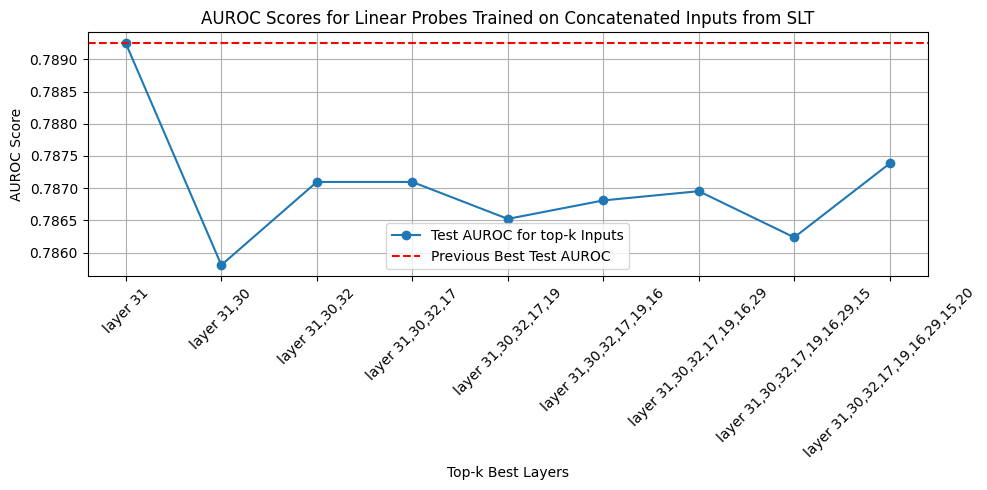

In [51]:
plot_metrics_w_constant(max(sablr_test_aucs), topksablr_test_aucs, 'SLT')

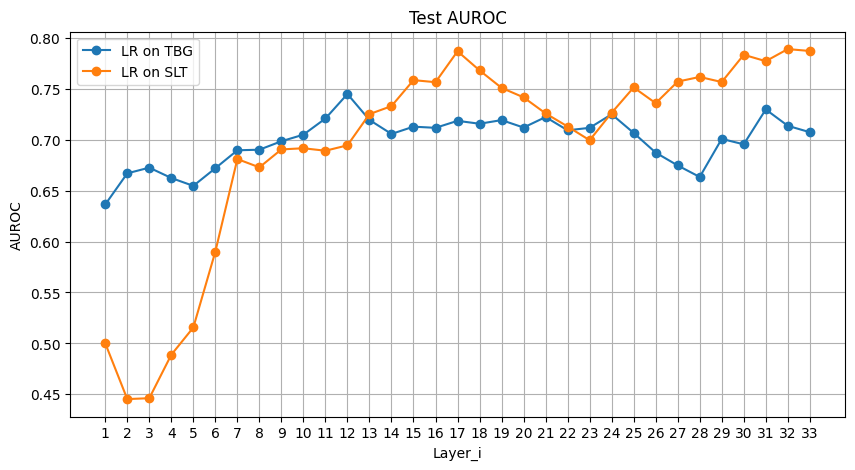

TBG: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7451 at 12 layer
SLT: max AUROC for LR trained on b-SE and tested on Accuracy: 0.7892 at 32 layer


In [52]:
# Compare TBG and SLT at predicting Acc from probes trained on b-SE
plot_1d_metrics([tablr_test_aucs, sablr_test_aucs], ['LR on TBG', 'LR on SLT'], 'AUROC')
print(f"TBG: max AUROC for LR trained on b-SE and tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on b-SE and tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")